# Multiple Linear Regression Analysis

This notebook builds and validates a multiple linear regression (MLR) models explaining photovoltaic power output potential (**PVOUT**) using the dataset created by `data_collection.ipynb`.

**Workflow:**
1. Setup the environment and load dataset.
2. Exploratory data analysis (distributions, correlations).
3. Fitting Regression line and backward elimination
4. Validate the final model.
5. Interpret selected model.

___
## 1. Setup

Add the local `lib` directory to the Python path and importing dependencies.

In [1]:
import sys
sys.path.insert(0, './lib')

#### Import Libraries

- `pandas` - data loading and manipulation
- `matplotlib.pyplot` - plotting
- `statsmodels.api` - OLS regression
- `variance_inflation_factor` - multicollinearity diagnostic (VIF)
- `het_breuschpagan` - homoscedasticity diagnostic (Breusch-Pagan test)
- `jarque_bera` - residual normality diagnostic

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

___
## Load Dataset

Import the merged dataset produced by the data collection pipeline.

In [3]:
url3 = r".\\data\\dataset.csv"
df3 = pd.read_csv(url3)

___
## 2. Exploratory Data Analysis (EDA)

Below parameters were used to get an overview of the dataset.

1. Summary of dataset
2. Box plots to identify outliers
3. Pearson correlation matrix
4. Scatter plots

### 2.1. Summary of the dataset

- Number of rows and columns
- 5 number summary

In [4]:
print(df3.shape)

print(df3.describe())

(125, 9)
         latitude   longitude  ALLSKY_SFC_SW_DWN   CLOUD_AMT  PRECTOTCORR  \
count  125.000000  125.000000         125.000000  125.000000   125.000000   
mean     7.561648   80.564720           5.331860   68.089824     4.396184   
std      1.043370    0.540732           0.212827    5.198160     0.770573   
min      5.950000   79.799000           5.027585   55.532500     2.881500   
25%      6.848000   80.114000           5.169755   64.837500     3.904500   
50%      7.323000   80.518000           5.363335   67.272000     4.413000   
75%      8.335000   80.957000           5.427010   71.659500     4.727000   
max      9.816000   81.849000           5.708520   76.347500     5.894000   

            RH2M         T2M        WS2M        pvout  
count  125.00000  125.000000  125.000000   125.000000  
mean    80.96664   26.506808    3.589080  1536.533661  
std      2.87174    1.414081    0.833881    61.073744  
min     76.78700   22.602500    2.319000  1367.495972  
25%     78.13350 

### 2.2. Box Plots

Boxplots to visualize the spread and identify potential outliers in each variable, first with `pvout` included, then without it (so the remaining variables, which are on much smaller scales, are not compressed by `pvout`'s larger range).

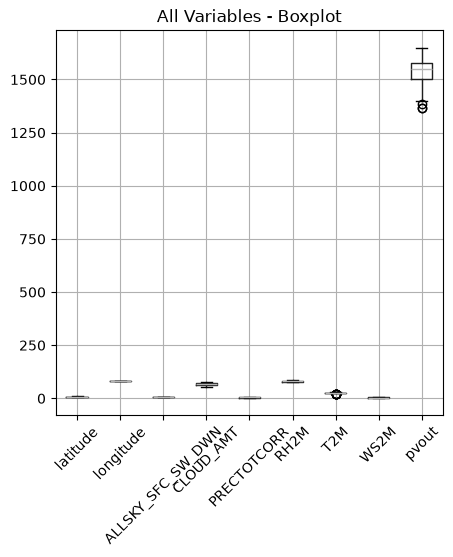

In [5]:
df3.boxplot(figsize=(5,5), rot=45)
plt.title('All Variables - Boxplot')
plt.show()

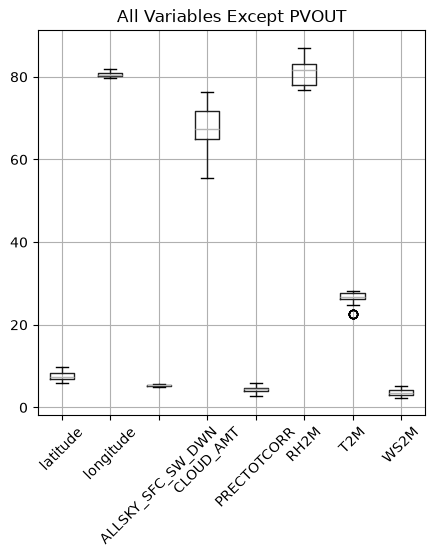

In [6]:
df3.drop(columns=['pvout']).boxplot(figsize=(5,5), rot=45)
plt.title('All Variables Except PVOUT')
plt.show()

#### **Addressing outliers**

Q1 = 25th percentile  
Q3 = 75th percentile  
IQR = Q3 - Q1  
Lower bound = Q1 - 1.5 * IQR  
Upper bound = Q3 + 1.5 * IQR

**code used to view outliers**
```python
df4 = df3
def get_outliers(df, col):
    Q1 = df4[col].quantile(0.25)
    Q3 = df4[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df4[col] < lower) | (df4[col] > upper)]

outliers = get_outliers(df4, ['pvout']) ; print(outliers)
outliers = get_outliers(df4, ['T2M']) ; print(outliers)
```

- Outliers detected via IQR method were NOT removed.
- These correspond to cooler-region/low-temperature (T2M) observations, which represent real climatological variation, not data errors. (Kandy)
- Removing them would bias the model by excluding valid cold-region conditions from the training data and understating pvout's actual range under low-temperature scenarios.


### 2.3. Pearson correlation matrix

A correlation matrix of the predictors and target gives an early read on which
variables might be redundant and which are most strongly associated with `y`
before any model is fit.

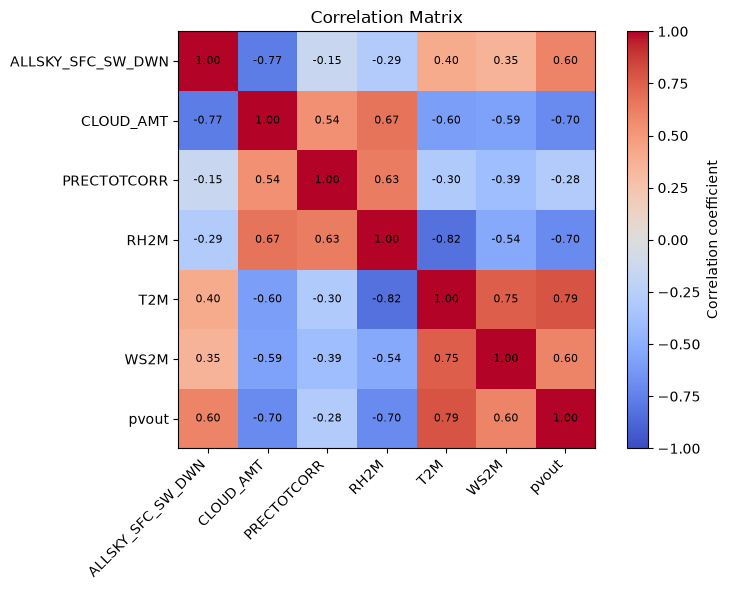

pvout                1.000000
T2M                  0.792156
ALLSKY_SFC_SW_DWN    0.598230
WS2M                 0.596851
PRECTOTCORR         -0.281639
CLOUD_AMT           -0.696008
RH2M                -0.700528
Name: pvout, dtype: float64

In [7]:
corr = df3.drop(columns=['latitude', 'longitude']).corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, label='Correlation coefficient')
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Correlation of each predictor with the target, sorted by strength
corr['pvout'].sort_values(ascending=False)

In [8]:
# NOTE:
# renamed long column names to shorter names (independent variables as 'from x1 to x6' and dependent variable as 'y').
# This is standard regression notation, keeps the code and `statsmodels` summary tables concise.

df3 = df3.rename(columns={
    'ALLSKY_SFC_SW_DWN': 'x1', # Irradiance
    'CLOUD_AMT'        : 'x2', # Cloud_Amount
    'PRECTOTCORR'      : 'x3', # Rainfall
    'RH2M'             : 'x4', # Humidity
    'T2M'              : 'x5', # Ambiant_Temperature
    'WS2M'             : 'x6', # Windspeed
    'pvout'            : 'y'
})

### 2.4. Scatter plots

Plotting each independent variable against `y` (`pvout`) to visualize basic trends
before modeling.

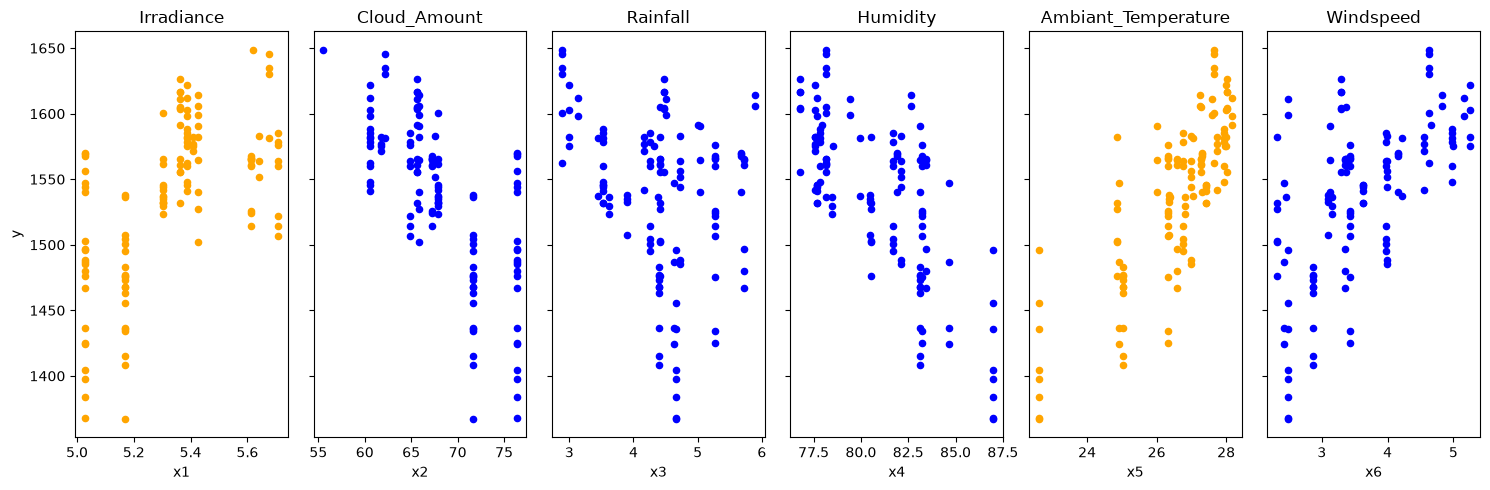

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(15, 5), sharey=True)

df3.plot.scatter(x='x1', y='y', ax=axes[0], color='orange', title='Irradiance')
df3.plot.scatter(x='x2', y='y', ax=axes[1], color='blue',   title='Cloud_Amount')
df3.plot.scatter(x='x3', y='y', ax=axes[2], color='blue',   title='Rainfall')
df3.plot.scatter(x='x4', y='y', ax=axes[3], color='blue',   title='Humidity')
df3.plot.scatter(x='x5', y='y', ax=axes[4], color='orange', title='Ambiant_Temperature')
df3.plot.scatter(x='x6', y='y', ax=axes[5], color='blue',   title='Windspeed')

plt.tight_layout()
plt.show()

___
## 3. Fitting Regression line and backward elimination

1. Regression Assumptions: Assumptions and criteria used to validate the models.
2. Fitting Lines: A base model is fitted with all dependent variables, then backward elimination is implemented for better fitting line.
    1. Base model (**M0**) - x1, x2, x3, x4, x5, x6
    2. Reduced model 1 (**M1**) - Dropped x2
    3. Reduced model 2 (**M2**) - Drop x5
    4. Reduced model 3 (**M3**) - Drop x2 and x5
3. Model Comparison Summary
4. Final Model Selection


## 3.1. Regression Assumptions

| Assumption | Test | Description |
|---|---|---|
| Statistical significance of predictors | t-test on each coefficient | `p > 0.05` = predictor is **NOT** statistically significant |
| No severe multicollinearity | Variance Inflation Factor (VIF) | `VIF > 5` = moderate concern, `VIF > 10` = severe concern |
| Homoscedasticity (constant error variance) | Breusch-Pagan test | Breusch-Pagan `p < 0.05` = reject homoscedasticity |
| Normally distributed residuals | Jarque-Bera test | Jarque-Bera `p < 0.05` = reject normality |
| No autocorrelation in residuals | Durbin-Watson statistic | 2.0 = no autocorrelation; well below 1.5 or above 2.5 = possible concern |
| Model parsimony vs. fit trade-off | AIC / BIC | Lower is better. A gap smaller than 2 (AIC) is not considered meaningful |


### 3.2.1 Base Model (M0) - x1, x2, x3, x4, x5, x6

In [10]:
X_M0 = df3[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']]
y = df3['y']
X_M0 = sm.add_constant(X_M0)

model_0 = sm.OLS(y, X_M0).fit()
print(model_0.summary())

vif_full = pd.DataFrame()
vif_full['feature'] = X_M0.columns
vif_full['VIF'] = [variance_inflation_factor(X_M0.values, i) for i in range(X_M0.shape[1])]
print(vif_full)

bp_stat, bp_p, _, _ = het_breuschpagan(model_0.resid, model_0.model.exog)
print(f"Breusch-Pagan p-value: {bp_p:.4f}")

jb_stat, jb_p, skew, kurtosis = jarque_bera(model_0.resid)
print(f"Jarque-Bera p-value: {jb_p:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     55.93
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           3.20e-32
Time:                        18:46:54   Log-Likelihood:                -606.72
No. Observations:                 125   AIC:                             1227.
Df Residuals:                     118   BIC:                             1247.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1244.3778    365.026      3.409      0.0

### Notes on M0:

- `04` Independent variables (`x2`, `x3`, `x5`, `x6`) are *not* significant.
- `02` Independent variables (`x4`, `x5`) shows severe multicollinearity.


### 3.2.2 Reduced Model 1 (M1) - Dropped `x2`

In [11]:
X_M1 = df3[['x1', 'x3', 'x4', 'x5', 'x6']]
X_M1 = sm.add_constant(X_M1)

model_1 = sm.OLS(y, X_M1).fit()
print(model_1.summary())

vif_c = pd.DataFrame()
vif_c['feature'] = X_M1.columns
vif_c['VIF'] = [variance_inflation_factor(X_M1.values, i) for i in range(X_M1.shape[1])]
print(vif_c)

bp_stat, bp_p, _, _ = het_breuschpagan(model_1.resid, model_1.model.exog)
print(f"Breusch-Pagan p-value: {bp_p:.4f}")

jb_stat, jb_p, skew, kurtosis = jarque_bera(model_1.resid)
print(f"Jarque-Bera p-value: {jb_p:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     67.57
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           3.95e-33
Time:                        18:46:54   Log-Likelihood:                -606.80
No. Observations:                 125   AIC:                             1226.
Df Residuals:                     119   BIC:                             1243.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1237.7700    363.284      3.407      0.0

### Notes on M1:

- `02` Independent variables (`x3`, `x6`) are *not* significant.
- `02` Independent variables (`x4`, `x5`) shows high multicollinearity.

### 3.2.3 Reduced Model 2 (M2) - Dropped `x5`

In [12]:
X_M2 = df3[['x1', 'x2', 'x3', 'x4', 'x6']]
X_M2 = sm.add_constant(X_M2)

model_2 = sm.OLS(y, X_M2).fit()
print(model_2.summary())

vif_c = pd.DataFrame()
vif_c['feature'] = X_M2.columns
vif_c['VIF'] = [variance_inflation_factor(X_M2.values, i) for i in range(X_M2.shape[1])]
print(vif_c)

bp_stat, bp_p, _, _ = het_breuschpagan(model_2.resid, model_2.model.exog)
print(f"Breusch-Pagan p-value: {bp_p:.4f}")

jb_stat, jb_p, skew, kurtosis = jarque_bera(model_2.resid)
print(f"Jarque-Bera p-value: {jb_p:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     64.74
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           2.53e-32
Time:                        18:46:54   Log-Likelihood:                -608.76
No. Observations:                 125   AIC:                             1230.
Df Residuals:                     119   BIC:                             1246.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1843.2710    206.637      8.920      0.0

### Notes on M2:

- `01` Independent variable (`x2`) are *not* significant.
- `01` Independent variable (`x2`) shows moderate multicollinearity.

### 3.2.4 Reduced Model 3 (M3) - Dropped `x2` and `x5`

In [13]:
X_M3 = df3[['x1', 'x3', 'x4', 'x6']]
X_M3 = sm.add_constant(X_M3)

model_3 = sm.OLS(y, X_M3).fit()
print(model_3.summary())

vif_d = pd.DataFrame()
vif_d['feature'] = X_M3.columns
vif_d['VIF'] = [variance_inflation_factor(X_M3.values, i) for i in range(X_M3.shape[1])]
print(vif_d)

bp_stat, bp_p, _, _ = het_breuschpagan(model_3.resid, model_3.model.exog)
print(f"Breusch-Pagan p-value: {bp_p:.4f}")

jb_stat, jb_p, skew, kurtosis = jarque_bera(model_3.resid)
print(f"Jarque-Bera p-value: {jb_p:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     81.44
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           2.86e-33
Time:                        18:46:54   Log-Likelihood:                -608.86
No. Observations:                 125   AIC:                             1228.
Df Residuals:                     120   BIC:                             1242.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1905.9273    143.167     13.313      0.0

### Notes on M3:

- `All` independent variables are significant.
- `All` independent variables do not shows multicollinearity.

___
#### NOTE:
> Further eliminations results weaker models. Therefore only above `04` models were considered.
___

### 3.3. Model comparison summary

| Metric                | M0 (all)               | M1 (Dropped `x2`)    | M2 (Dropped `x5`)    | M3 (Dropped `x2`, `x5`) |
|:---:|:---:|:---:|:---:|:---:|
| R-squared             | 0.740                  | 0.740                |  0.731               | 0.731                   |
| Adj. R-squared        | 0.727                  | 0.729                | 0.720                | 0.722                   |
| All predictors significant | No (`x2`,`x3`,`x5`,`x6` fail) | No (`x3`,`x6` fail)       | No (`x2` fails)      | **Yes**         |
| Max VIF                    | 12.81 (`x5`), 12.77 (`x4`)    | 10.87 (`x5`), 9.05 (`x4`) | 6.85 (`x2`)          | **2.01** (`x4`) |
| Breusch-Pagan p-value | 0.0764                 | 0.0658               | 0.1110               | 0.0857                  |
| Jarque-Bera p-value   | 0.1382                 | 0.1229               | 0.0662               | 0.0798                  |
| AIC                   | 1227                   | 1226                 | 1230                 | 1228                    |
| BIC                   | 1247                   | 1243                 | 1246                 | **1242**                |


### 3.4. Final Model Selection

1. **All independent variables are significant**
    - M4 is the only model where every remaining predictor (x1, x3, x4, x6).
    - Every other model carries at least one non-significant term

2. **No multicollinearity.**

- M3's VIFs are the lowest and most uniform of any model, all under 2.1.
    - x1=1.16
    - x3=1.66
    - x4=2.01
    - x6=1.51

- M0, M1 and M2 all have at least one variable with `VIF > 5` (moderate concern).

- M0 and M1 have variables with `VIF > 10` (severe concern).

3. **Fitting cost is negligible.**
- `M1` has maximum `Adj. R-squared` = **0.729**
- `M3` has`Adj. R-squared` = **0.722**, which is only 0.007 difference.

___

#### Therefore `M3 (drop x2, x5)` is the optimum model based on significance, multicollinearity, homoscedasticity and normality.
___

## 4. Validate the final model.

Visual checks to model is valid within assumptions:
1. Residuals vs. Fitted plot (checks for non-linearity and heteroscedasticity patterns)
2. Normal Q-Q plot (checks residual normality).

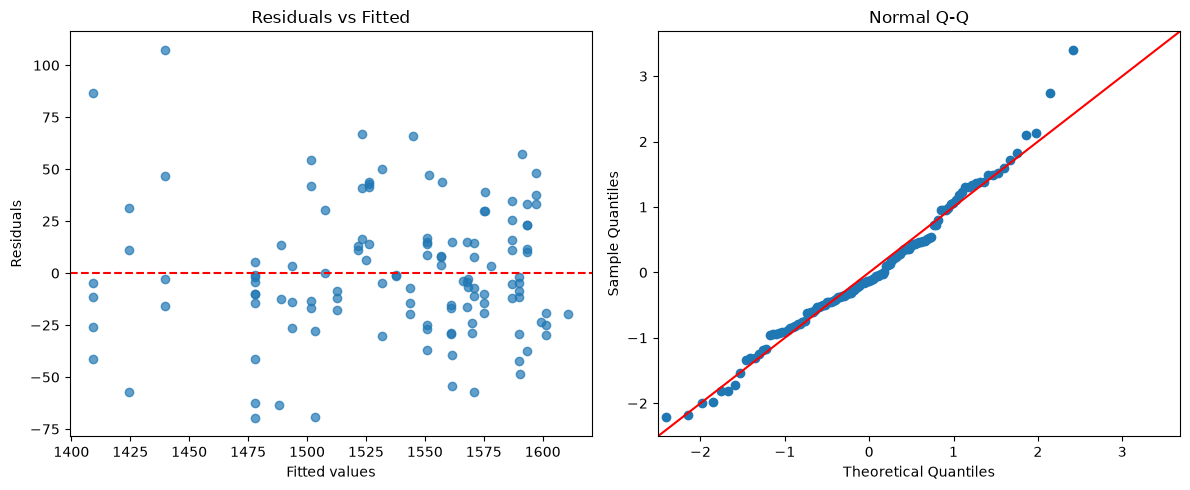

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Fitted
axes[0].scatter(model_3.fittedvalues, model_3.resid, alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Normal Q-Q
sm.qqplot(model_3.resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Normal Q-Q')

plt.tight_layout()
plt.show()

#### Results:
> No funnel or curve shape in Residuals vs. Fitted (consistent with the passing Breusch-Pagan result).
> 
> points tracking the 45° line reasonably closely in the Normal Q-Q plot (consistent with the passing Jarque-Bera result).

___
## 5. Final Model Interpretation

**Equation:**

`y = (107.7544) x1 + (20.5331) x3 − (13.5037) x4 + (16.4832) x6`

Where:
- `y` = PVOUT (`photovoltaic power output potential` - kWh/year)
- `x1` = solar irradiance (`ALLSKY_SFC_SW_DWN`)
- `x3` = rainfall (`PRECTOTCORR`)
- `x4` = relative humidity (`RH2M`)
- `x6` = wind speed (`WS2M`)

1. **x1 (irradiance)**: the largest-magnitude, most directly explainable coefficient in the model.
    - Higher solar irradiance is leads to substantially higher PVOUT.
    - Well align with physics behind solar energy production

2. **x4 (humidity)**:
    - higher relative humidity is leads to lower PVOUT
    - align with physics theory, atmospheric moisture/cloud cover reducing surface solar radiation.

3. **x3 (rainfall)**:
    - higher rainfall is associated with *higher* PVOUT.
    - This is not the direction a physics theory would predict (more rain should means more cloud cover and less sun, hence less PVOUT).
    - This result can be explained as below,
        1. This is a cross-sectional analysis, yearly average data is used for climatology data, therefore no seasonality effects are covered. (e.g. Monsoon Season, Rainfall during night-time also included even there is zero effect on PVOUT)
        2. Some research suggest that rain clean dust on the solar panels, leading to slightly better performance. Therefore that may be affecting the results, since Sri Lanka has 02 monsoon seasons and continuous rainfall throughout the year.
    - This should not be read as "more rain improves solar power output", without further investigation.

4. **x6 (wind speed)**:

    - higher wind speed is associated with higher PVOUT.
    - There is no clear direct physics theory linking wind speed to a modeled solar resource potential. This can be explained as below,
        1. Solar panel temperature keep increasing during day-time, research confirms extreme temperatures lead to reduces efficiency in solar panels. Constant Wind can cool down the solar panels, leading to positive coefficient.
        2. Windier locations geographically coinciding with higher-irradiance locations (e.g. coastal/open exposure), which can be leads to a positive coefficient.
    - This condition also can benefitted from further investigation.

___
**Overall Model:** Adjusted R² = 0.722 (the model explains around 72% of the variance in PVOUT across the 125 locations), all predictors significant at p < 0.001, no meaningful multicollinearity (max VIF = 2.01), passes both Breusch-Pagan and Jarque-Bera.
___